
🚀 Starting Project...
✅ Data Loaded


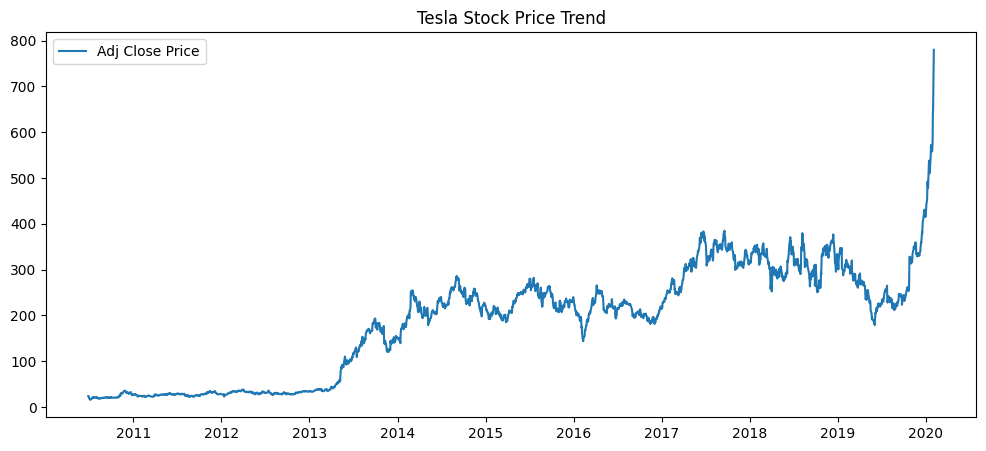

✅ Data Prepared



🔥 Training RNN...
Epoch 1/20

59/59 [==============================] - 5s 33ms/step - loss: 0.0327
Epoch 2/20
59/59 [==============================] - 2s 33ms/step - loss: 0.0095
Epoch 3/20
59/59 [==============================] - 2s 35ms/step - loss: 0.0049
Epoch 4/20
59/59 [==============================] - 2s 34ms/step - loss: 0.0036
Epoch 5/20
59/59 [==============================] - 2s 33ms/step - loss: 0.0029
Epoch 6/20
59/59 [==============================] - 2s 36ms/step - loss: 0.0023
Epoch 7/20
59/59 [==============================] - 2s 35ms/step - loss: 0.0020
Epoch 8/20
59/59 [==============================] - 2s 35ms/step - loss: 0.0016
Epoch 9/20
59/59 [==============================] - 2s 34ms/step - loss: 0.0015
Epoch 10/20
59/59 [==============================] - 2s 34ms/step - loss: 0.0013
Epoch 11/20
59/59 [==============================] - 2s 34ms/step - loss: 0.0012
Epoch 12/20
59/59 [==============================] - 2s 34ms/step - loss: 0.0011

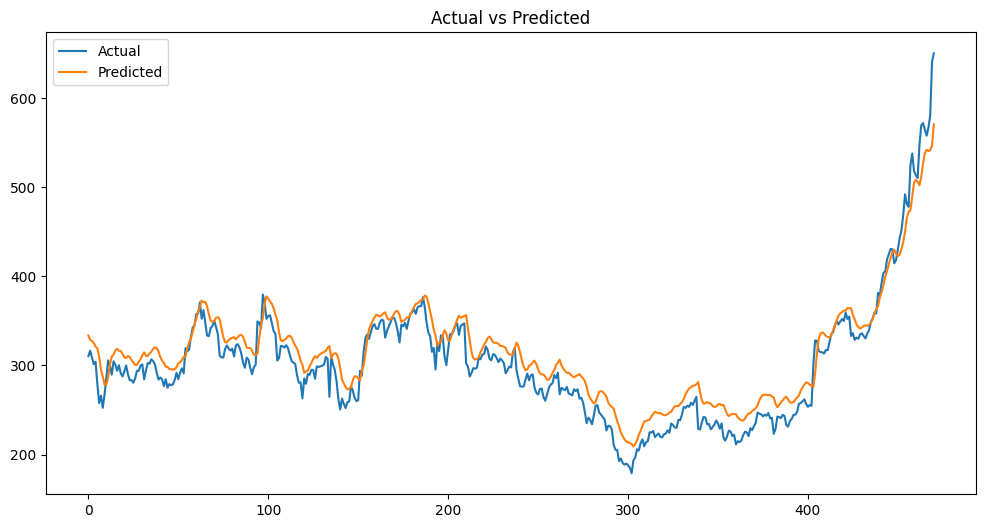

📉 LSTM MSE: 480.8162181216116

🔮 Future Predictions:
1 days: [649.2524]
5 days: [649.2524  641.503   627.4576  609.5183  590.27106]
10 days: [649.2524  641.503   627.4576  609.5183  590.27106 571.2965  553.4536
 537.1489  522.51746 509.53775]

✅ MODEL SAVED: E:\TeslaStockPrediction\outputs\models\lstm_model.keras
📦 Model Size: 0.21 MB
⚠️ Model is small but still valid for deployment


In [1]:
# =========================================
# TESLA STOCK PRICE PREDICTION 
# =========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN, LSTM
from tensorflow.keras import Input

print("🚀 Starting Project...")

# =========================================
# LOAD DATA
# =========================================
df = pd.read_csv('../data/TSLA.csv')

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

df = df.ffill()

print("✅ Data Loaded")

# =========================================
# VISUALIZATION
# =========================================
plt.figure(figsize=(12,5))
plt.plot(df['Adj Close'], label='Adj Close Price')
plt.title("Tesla Stock Price Trend")
plt.legend()
plt.show()

# =========================================
# FEATURE SELECTION
# =========================================
data = df[['Adj Close']]

# =========================================
# SCALING
# =========================================
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# =========================================
# CREATE DATASET
# =========================================
def create_dataset(data, time_step=60):
    X, y = [], []
    for i in range(len(data)-time_step-1):
        X.append(data[i:(i+time_step), 0])
        y.append(data[i+time_step, 0])
    return np.array(X), np.array(y)

time_step = 60
X, y = create_dataset(scaled_data, time_step)

X = X.reshape(X.shape[0], X.shape[1], 1)

# =========================================
# TRAIN TEST SPLIT
# =========================================
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print("✅ Data Prepared")

# =========================================
# RNN MODEL
# =========================================
model_rnn = Sequential([
    Input(shape=(60,1)),
    SimpleRNN(50, return_sequences=True),
    Dropout(0.2),
    SimpleRNN(50),
    Dropout(0.2),
    Dense(1)
])

model_rnn.compile(optimizer='adam', loss='mean_squared_error')

print("\n🔥 Training RNN...")
model_rnn.fit(X_train, y_train, epochs=20, batch_size=32, verbose=1)

# =========================================
# LSTM MODEL (FINAL)
# =========================================
model_lstm = Sequential([
    Input(shape=(60,1)),   # ✅ important fix
    LSTM(64),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mean_squared_error')

print("\n🔥 Training LSTM...")
history = model_lstm.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    shuffle=False,
    verbose=1
)

print("✅ Training completed")

# =========================================
# PREDICTIONS
# =========================================
pred_lstm = model_lstm.predict(X_test)
pred_lstm = scaler.inverse_transform(pred_lstm)

y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

# =========================================
# PLOT RESULTS
# =========================================
plt.figure(figsize=(12,6))
plt.plot(y_test_actual, label='Actual')
plt.plot(pred_lstm, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

# =========================================
# EVALUATION
# =========================================
mse = mean_squared_error(y_test_actual, pred_lstm)
print("📉 LSTM MSE:", mse)

# =========================================
# FUTURE PREDICTIONS
# =========================================
def predict_future(days):
    temp_input = list(scaled_data[-60:])
    predictions = []

    for i in range(days):
        x_input = np.array(temp_input[-60:])
        x_input = x_input.reshape(1,60,1)

        pred = model_lstm.predict(x_input, verbose=0)
        temp_input.append(pred[0])
        predictions.append(pred[0][0])

    return scaler.inverse_transform(np.array(predictions).reshape(-1,1))

print("\n🔮 Future Predictions:")
for d in [1,5,10]:
    print(f"{d} days:", predict_future(d).flatten())

# =========================================
# SAVE MODEL (DEPLOYMENT SAFE)
# =========================================
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
model_dir = os.path.join(BASE_DIR, "outputs", "models")

os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, "lstm_model.keras")

# Remove old model (important)
if os.path.exists(model_path):
    os.remove(model_path)

# Save model
model_lstm.save(model_path)

print("\n✅ MODEL SAVED:", model_path)

# =========================================
# VERIFY FILE SIZE
# =========================================
file_size = os.path.getsize(model_path) / (1024 * 1024)
print(f"📦 Model Size: {file_size:.2f} MB")

if file_size < 0.5:
    print("⚠️ Model is small but still valid for deployment")
else:
    print("✅ Model saved correctly")